In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torchvision.models as models
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from PIL import Image
import numpy as np
import os
import random
import zipfile

In [2]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [18]:

from torchvision.datasets import CIFAR10
import os

dataset = CIFAR10(root='/content/data', download=True)

DATASET_PATH = "/content/cifar_images"
os.makedirs(DATASET_PATH, exist_ok=True)

for i, (img, label) in enumerate(dataset):
    class_name = dataset.classes[label]
    class_dir = os.path.join(DATASET_PATH, class_name)
    os.makedirs(class_dir, exist_ok=True)

    img.save(os.path.join(class_dir, f"{i}.png"))

print("CIFAR dataset ready at:", DATASET_PATH)

100%|██████████| 170M/170M [00:03<00:00, 48.2MB/s]


CIFAR dataset ready at: /content/cifar_images


In [19]:

def get_image_paths(folder):
    valid_ext = ('.jpg', '.jpeg', '.png', '.bmp')
    paths = []

    for root, _, files in os.walk(folder):
        for file in files:
            if file.lower().endswith(valid_ext):
                paths.append(os.path.join(root, file))

    return paths

image_paths = get_image_paths(DATASET_PATH)
print(f"Total images found: {len(image_paths)}")

Total images found: 50000


In [33]:
transform = transforms.Compose([
    transforms.Resize((256, 256)),
   # transforms.Grayscale(num_output_channels=3)
    transforms.ToTensor()
])

def load_image(path):
    img = Image.open(path).convert("RGB")
    img = transform(img).unsqueeze(0)
    return img.to(device)

In [34]:
class VGGFeatureExtractor(nn.Module):
    def __init__(self):
        super().__init__()
        vgg = models.vgg16(weights=models.VGG16_Weights.IMAGENET1K_V1).features

        self.layers = nn.ModuleList([
            vgg[:4],
            vgg[4:9],
            vgg[9:16],
            vgg[16:23],
        ])

        for p in self.parameters():
            p.requires_grad = False

    def forward(self, x):
        feats = []
        for layer in self.layers:
            x = layer(x)
            feats.append(x)
        return feats

In [35]:
def extract_patches(fmap, patch_size=8):
    patches = fmap.unfold(2, patch_size, patch_size).unfold(3, patch_size, patch_size)
    return patches.contiguous().view(-1, patch_size * patch_size)

def wasserstein_distance_1d(p, q):
    p_sorted, _ = torch.sort(p, dim=1)
    q_sorted, _ = torch.sort(q, dim=1)
    return torch.mean(torch.abs(p_sorted - q_sorted))

In [36]:
class DeepDistributionIQA(nn.Module):
    def __init__(self, extractor):
        super().__init__()
        self.extractor = extractor

    def forward(self, x, y):
        fx = self.extractor(x)
        fy = self.extractor(y)

        loss = 0
        for f1, f2 in zip(fx, fy):
            p1 = extract_patches(f1)
            p2 = extract_patches(f2)
            loss += wasserstein_distance_1d(p1, p2)

        return loss / len(fx)

In [37]:

def total_variation_loss(img):
    return torch.mean(torch.abs(img[:, :, :-1] - img[:, :, 1:])) + \
           torch.mean(torch.abs(img[:, :-1, :] - img[:, 1:, :]))

def multi_scale_loss(model, output, target):
    loss = 0
    for scale in [1, 0.5, 0.25]:
        out_s = F.interpolate(output, scale_factor=scale, mode='bilinear', align_corners=False)
        tgt_s = F.interpolate(target, scale_factor=scale, mode='bilinear', align_corners=False)
        loss += model(out_s, tgt_s)
    return loss

def total_loss(model, output, target):
    wsd = multi_scale_loss(model, output, target)
    l1 = torch.mean(torch.abs(output - target))
    tv = total_variation_loss(output)
    return wsd + 0.5*l1 + 0.2*tv

In [38]:
def reconstruct_from_blank(model, reference, steps=300):

    reference = reference.to(device)

    #  START FROM BLANK
    optimized = torch.ones_like(reference).to(device) * 0.5
    optimized.requires_grad_(True)

    optimizer = torch.optim.Adam([optimized], lr=0.01)

    for i in range(steps):
        optimizer.zero_grad()

        loss = total_loss(model, optimized, reference)
        loss.backward()

        optimizer.step()

        with torch.no_grad():
            optimized.clamp_(0, 1)

        if i % 20 == 0:
            print(f"Step {i}: {loss.item():.4f}")

    return optimized.detach()

In [39]:
def compute_enhancement_blank(model, ref, reconstructed):
    blank = torch.ones_like(ref) * 0.5

    before = model(blank, ref).item()
    after = model(reconstructed, ref).item()

    improvement = (before - after) / (before + 1e-8) * 100
    return improvement, before, after

In [27]:
extractor = VGGFeatureExtractor().to(device).eval()
model = DeepDistributionIQA(extractor).to(device)

In [40]:
n = 2
selected_paths = random.sample(image_paths, n)

for p in selected_paths:
    print(p)

/content/cifar_images/ship/13967.png
/content/cifar_images/ship/17442.png


In [41]:

import shutil
import os

OUTPUT_DIR = "/content/output_results"

# Remove old results
if os.path.exists(OUTPUT_DIR):
    shutil.rmtree(OUTPUT_DIR)

os.makedirs(OUTPUT_DIR, exist_ok=True)

print("Output directory ready (clean).")

Output directory ready (clean).


In [42]:

def save_images(blank, ref, rec, idx):
    blank_np = blank.squeeze().permute(1,2,0).cpu().numpy()
    ref_np = ref.squeeze().permute(1,2,0).cpu().numpy()
    rec_np = rec.squeeze().permute(1,2,0).cpu().numpy()

    #valid values
    blank_np = np.clip(blank_np, 0, 1)
    ref_np = np.clip(ref_np, 0, 1)
    rec_np = np.clip(rec_np, 0, 1)

    plt.imsave(f"{OUTPUT_DIR}/blank_{idx}.png", blank_np)
    plt.imsave(f"{OUTPUT_DIR}/reconstructed_{idx}.png", rec_np)
    plt.imsave(f"{OUTPUT_DIR}/reference_{idx}.png", ref_np)

    fig = plt.figure(figsize=(12,4))

    plt.subplot(1,3,1)
    plt.imshow(blank_np)
    plt.title(f"Blank ({idx})")
    plt.axis("off")

    plt.subplot(1,3,2)
    plt.imshow(rec_np)
    plt.title(f"Reconstructed ({idx})")
    plt.axis("off")

    plt.subplot(1,3,3)
    plt.imshow(ref_np)
    plt.title(f"Reference ({idx})")
    plt.axis("off")

    fig.savefig(f"{OUTPUT_DIR}/comparison_{idx}.png")
    plt.close(fig)

In [43]:
results = []

for i, path in enumerate(selected_paths):
    print(f"\nProcessing {i+1}/{n}")

    reference = load_image(path)

    reconstructed = reconstruct_from_blank(model, reference)

    improvement, before, after = compute_enhancement_blank(
        model, reference, reconstructed
    )

    results.append(improvement)

    print(f"Before: {before:.4f}")
    print(f"After : {after:.4f}")
    print(f"Improvement: {improvement:.2f}%")

    #initial blank image
    blank = torch.ones_like(reference) * 0.5

    save_images(blank, reference, reconstructed, idx=i+1)

    print("="*50)


Processing 1/2
Step 0: 0.7554
Step 20: 0.4203
Step 40: 0.3010
Step 60: 0.2161
Step 80: 0.1504
Step 100: 0.1070
Step 120: 0.0815
Step 140: 0.0632
Step 160: 0.0535
Step 180: 0.0472
Step 200: 0.0426
Step 220: 0.0381
Step 240: 0.0350
Step 260: 0.0330
Step 280: 0.0311
Before: 0.1256
After : 0.0058
Improvement: 95.40%

Processing 2/2
Step 0: 0.7613
Step 20: 0.4637
Step 40: 0.3625
Step 60: 0.2997
Step 80: 0.2551
Step 100: 0.2212
Step 120: 0.1951
Step 140: 0.1746
Step 160: 0.1561
Step 180: 0.1405
Step 200: 0.1260
Step 220: 0.1138
Step 240: 0.1031
Step 260: 0.0936
Step 280: 0.0854
Before: 0.1090
After : 0.0109
Improvement: 90.03%



===== FINAL REPORT =====
Images processed: 2

--- Individual Improvements ---
Image 1: 95.40%
Image 2: 90.03%

--- Summary ---
Average Improvement: 92.72%
 >50% Enhancement Achieved


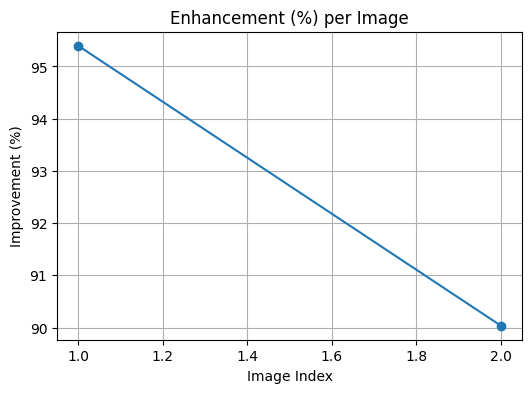

In [45]:

import matplotlib.pyplot as plt
import numpy as np

avg = np.mean(results)

print("\n===== FINAL REPORT =====")
print(f"Images processed: {n}")

print("\n--- Individual Improvements ---")
for i, val in enumerate(results):
    print(f"Image {i+1}: {val:.2f}%")

print("\n--- Summary ---")
print(f"Average Improvement: {avg:.2f}%")

if avg >= 50:
    print(" >50% Enhancement Achieved")
else:
    print(" Not Achieved")


with open(f"{OUTPUT_DIR}/results.txt", "w") as f:
    for i, val in enumerate(results):
        f.write(f"Image {i+1}: {val:.2f}%\n")
    f.write(f"\nAverage Improvement: {avg:.2f}%\n")

plt.figure(figsize=(6,4))
plt.plot(range(1, len(results)+1), results, marker='o')

plt.title("Enhancement (%) per Image")
plt.xlabel("Image Index")
plt.ylabel("Improvement (%)")
plt.grid()

plt.savefig(f"{OUTPUT_DIR}/improvement_plot.png")
plt.show()